# AAAAAAAAAAAAAAA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [2]:
# --- Configurações ---
caminho_arquivo = r"REG_VOO\VOO_094.csv" # Substitua pelo nome do seu arquivo de log
HIL_MODE = False  # Defina como True se estiver usando HIL
# Parâmetro de Suavização (Média Móvel)
TAMANHO_JANELA_MEDIA_MOVEL = 10

# Nomes das colunas para corresponder ao seu arquivo CSV
nomes_colunas = [
    "Time[ms]", "AccX[g]", "AccY[g]", "AccZ[g]", 
    "GyroX[°/s]", "GyroY[°/s]", "GyroZ[°/s]", 
    "MagX[uT]", "MagY[uT]", "MagZ[uT]", 
    "qW", "qX", "qY", "qZ", 
    "AltFilt[m]", "VelFilt[m/s]", "AccVert[m/s^2]", 
    "Tilt[°]", "PressBMP[Pa]", "Servo[%]", "Gain1", "Gain2", "Estado"
]

if HIL_MODE:
    tempo_espera = 19.5
else:
    tempo_espera = 0.0


C:\Users\Fefon\AppData\Local\Temp\ipykernel_13540\1677197117.py:265: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=[0, 0, 1, 0.95])


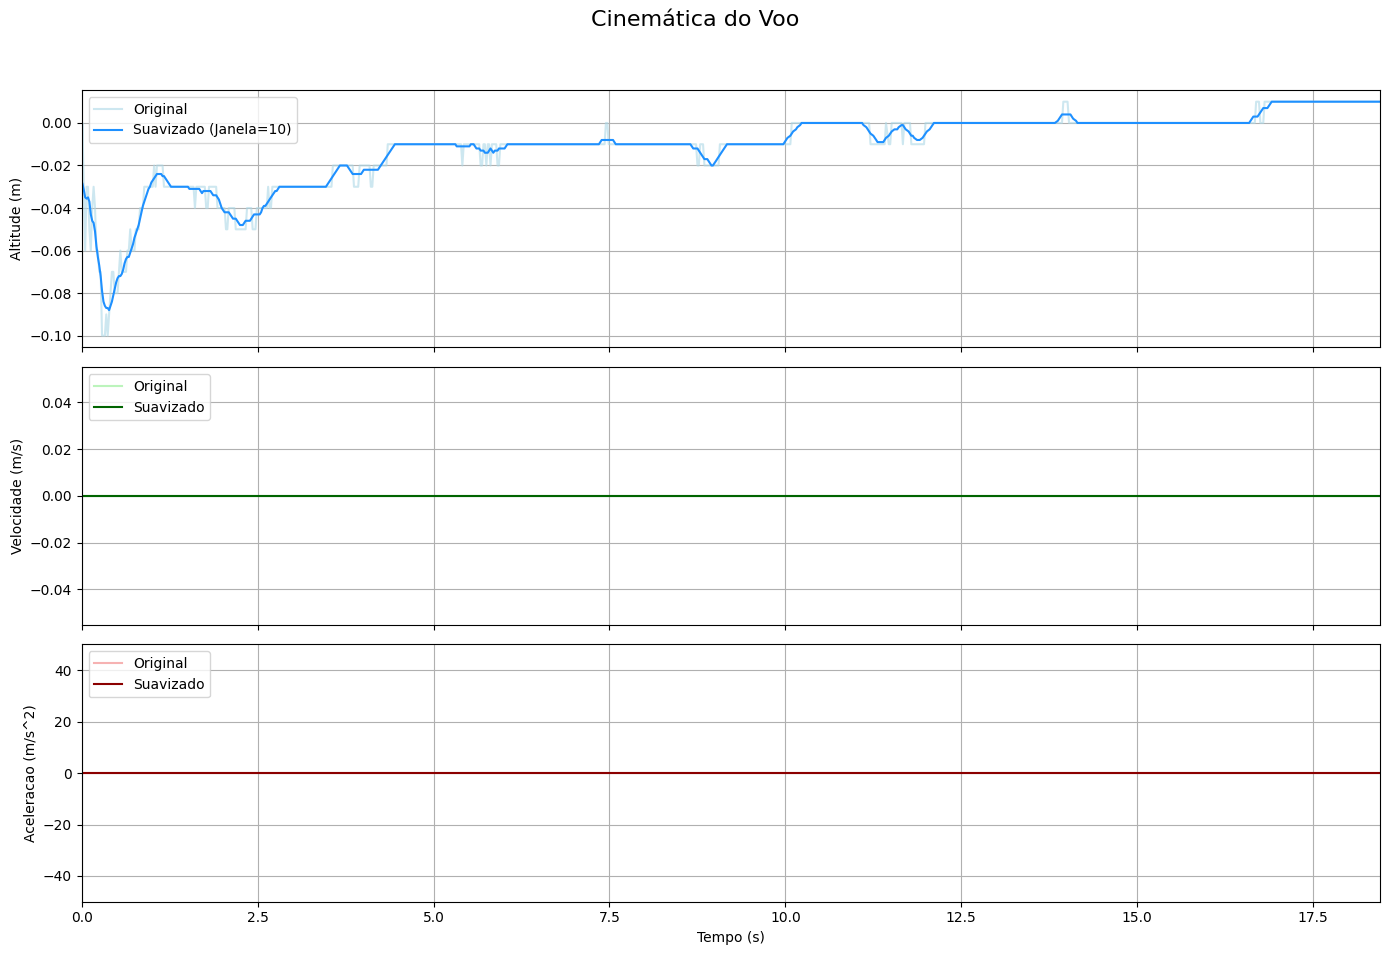

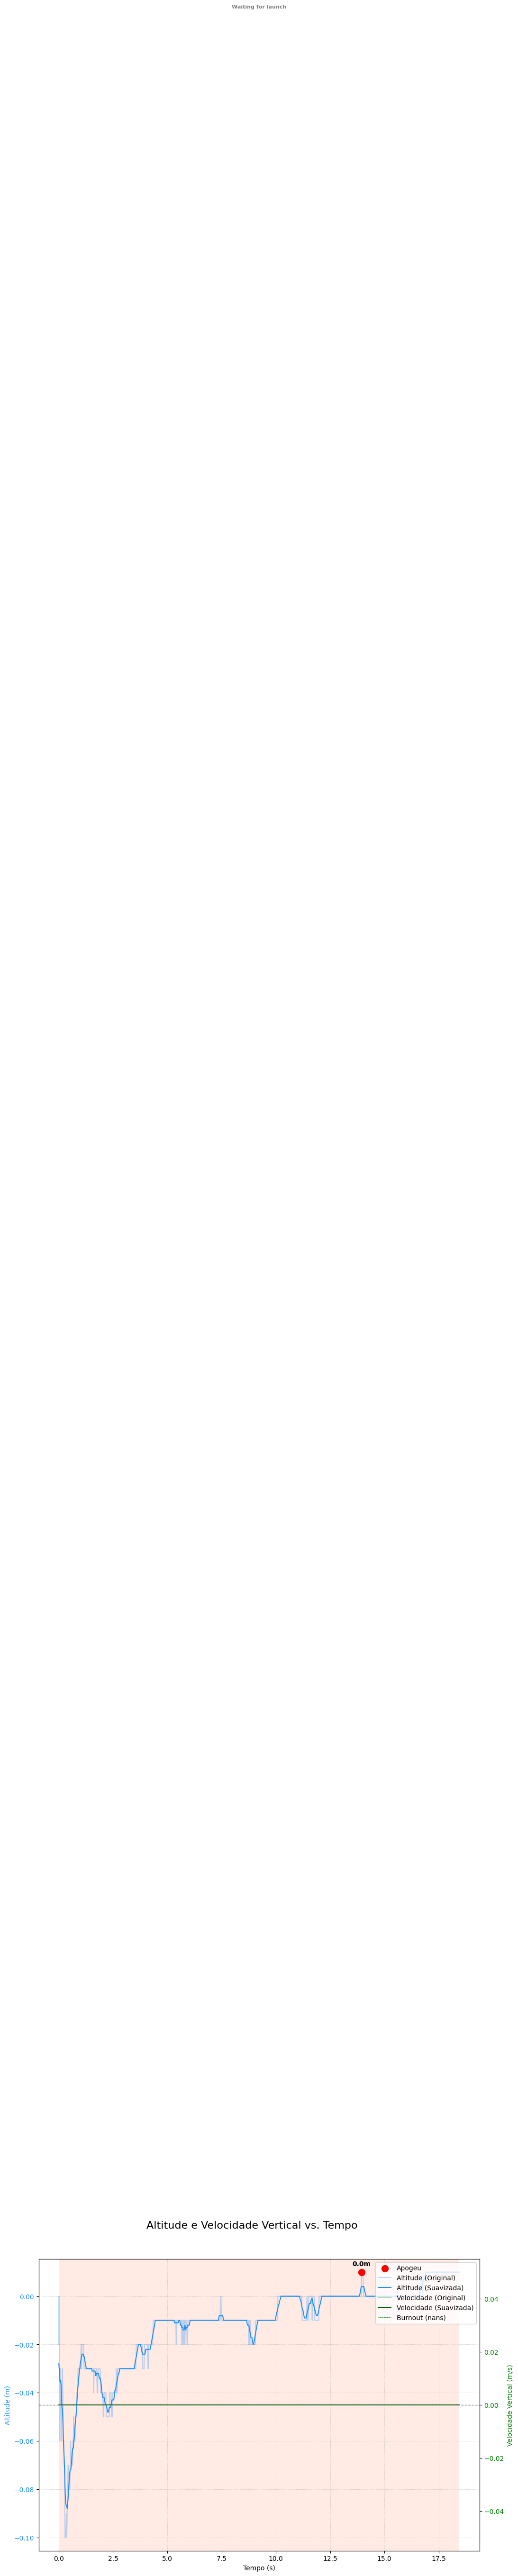

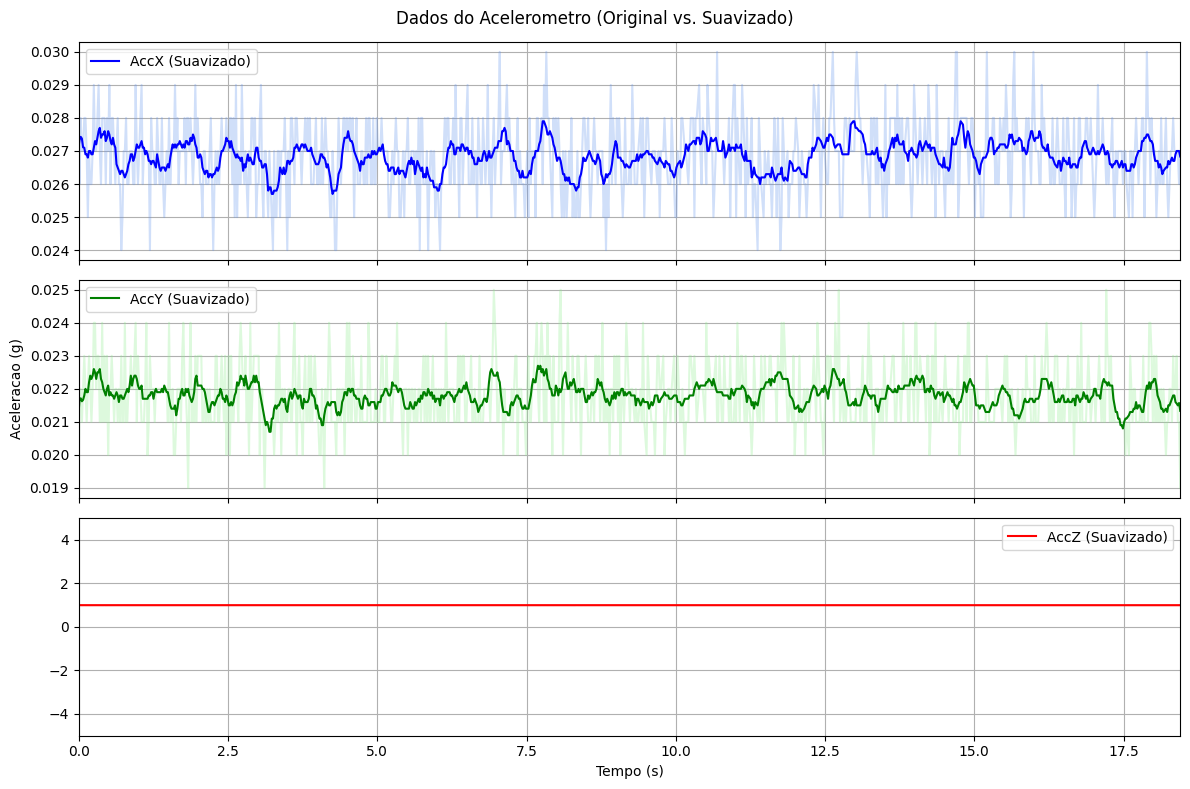

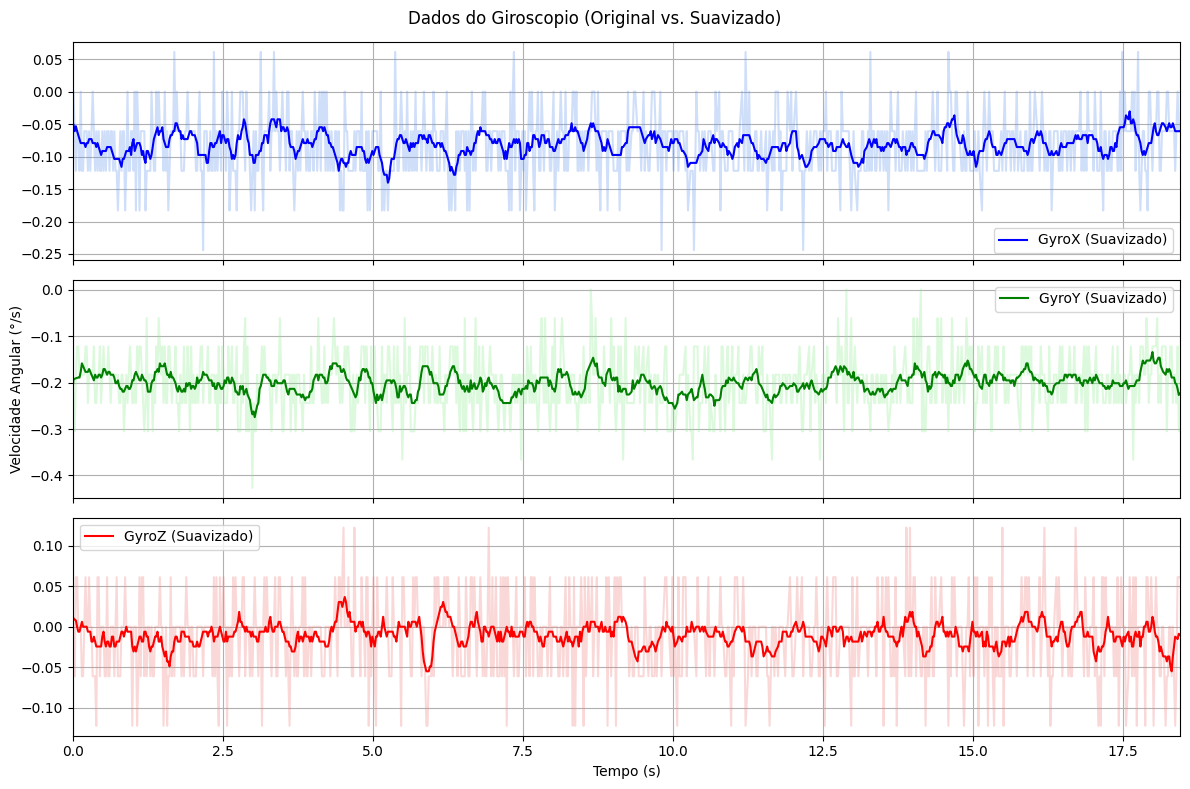

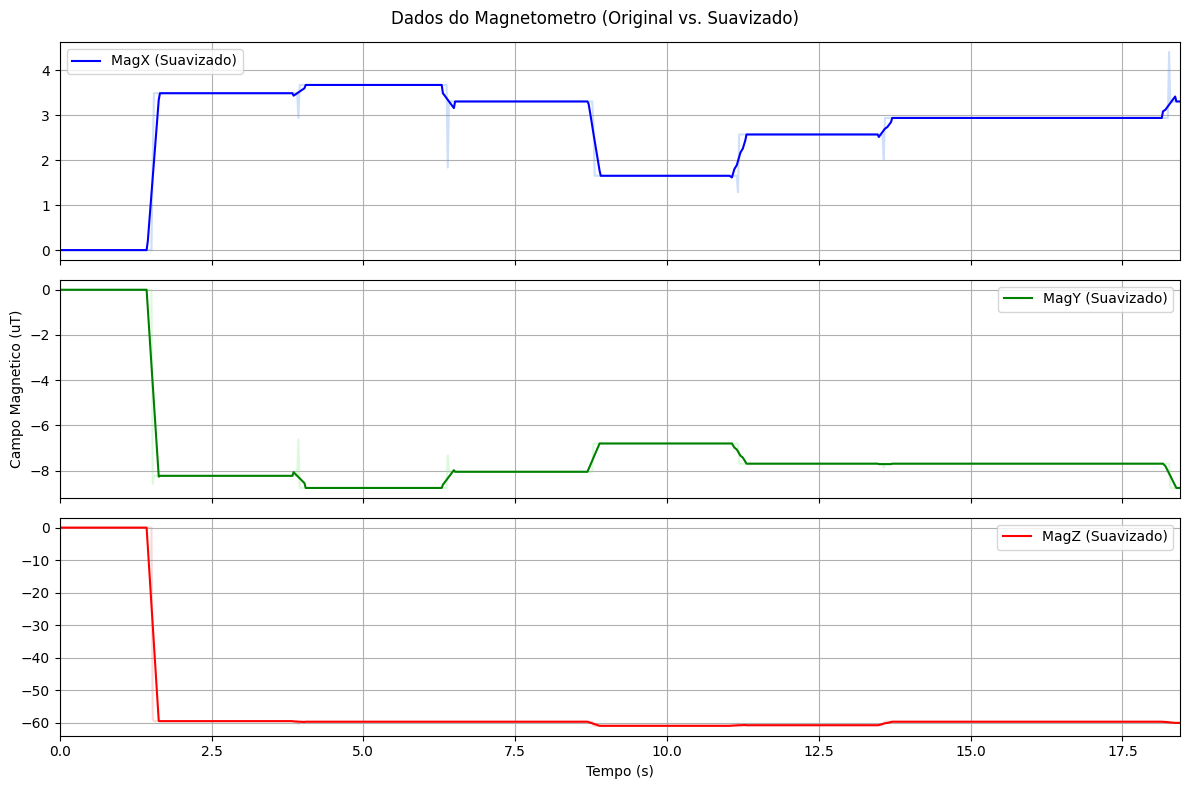

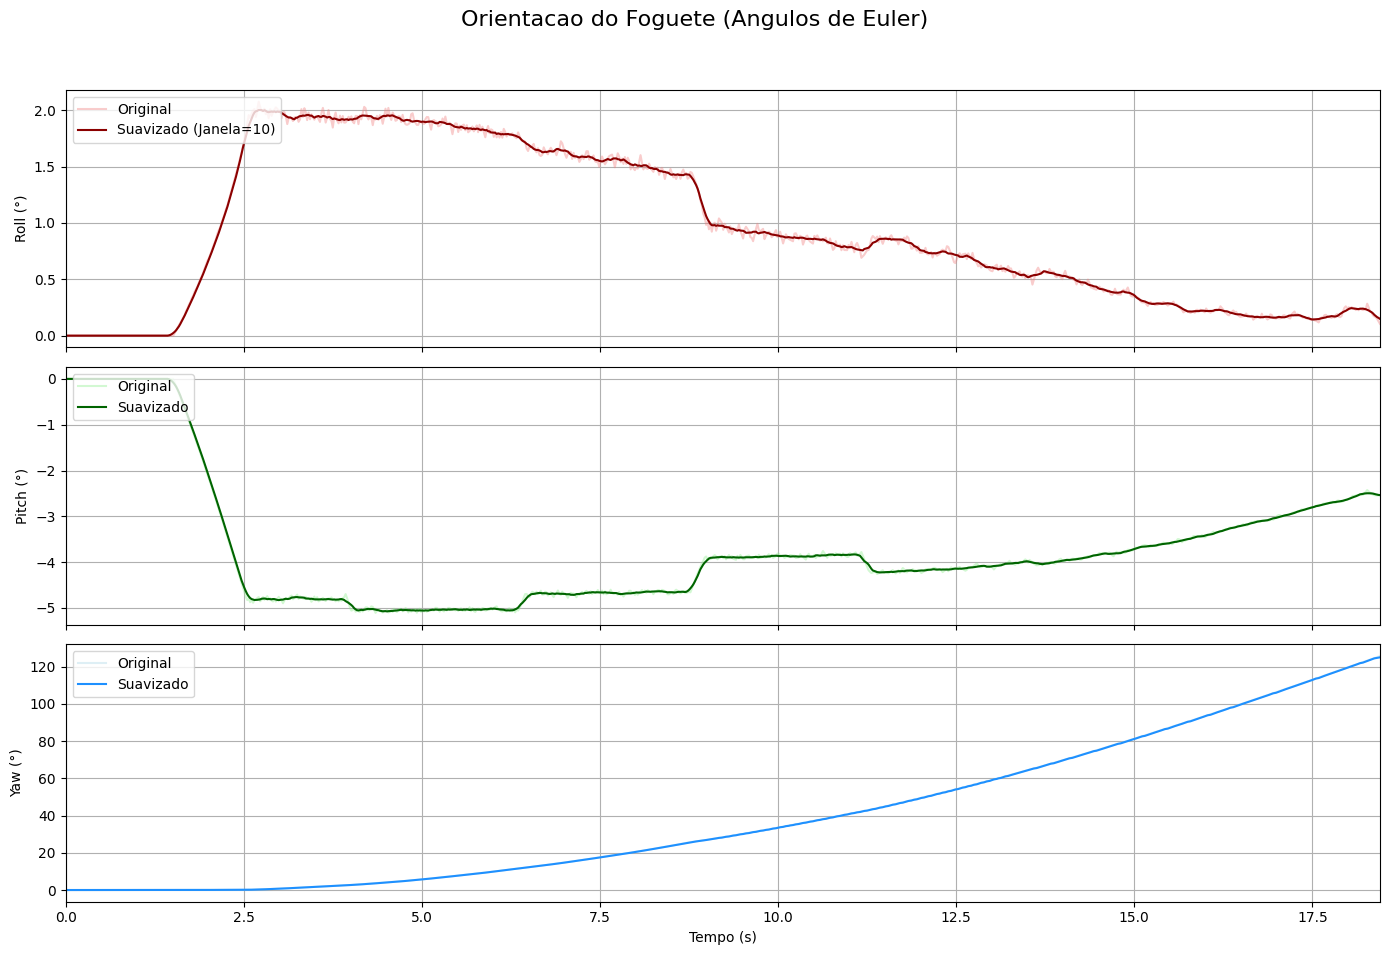

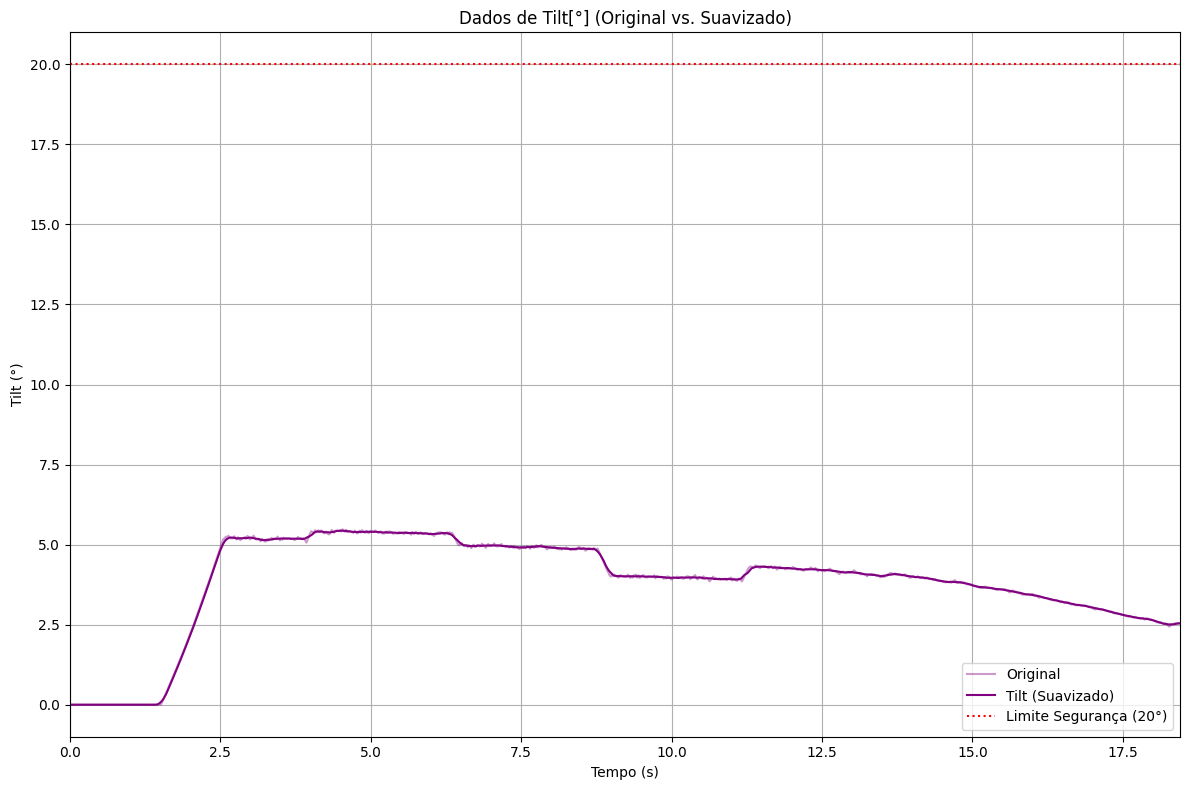

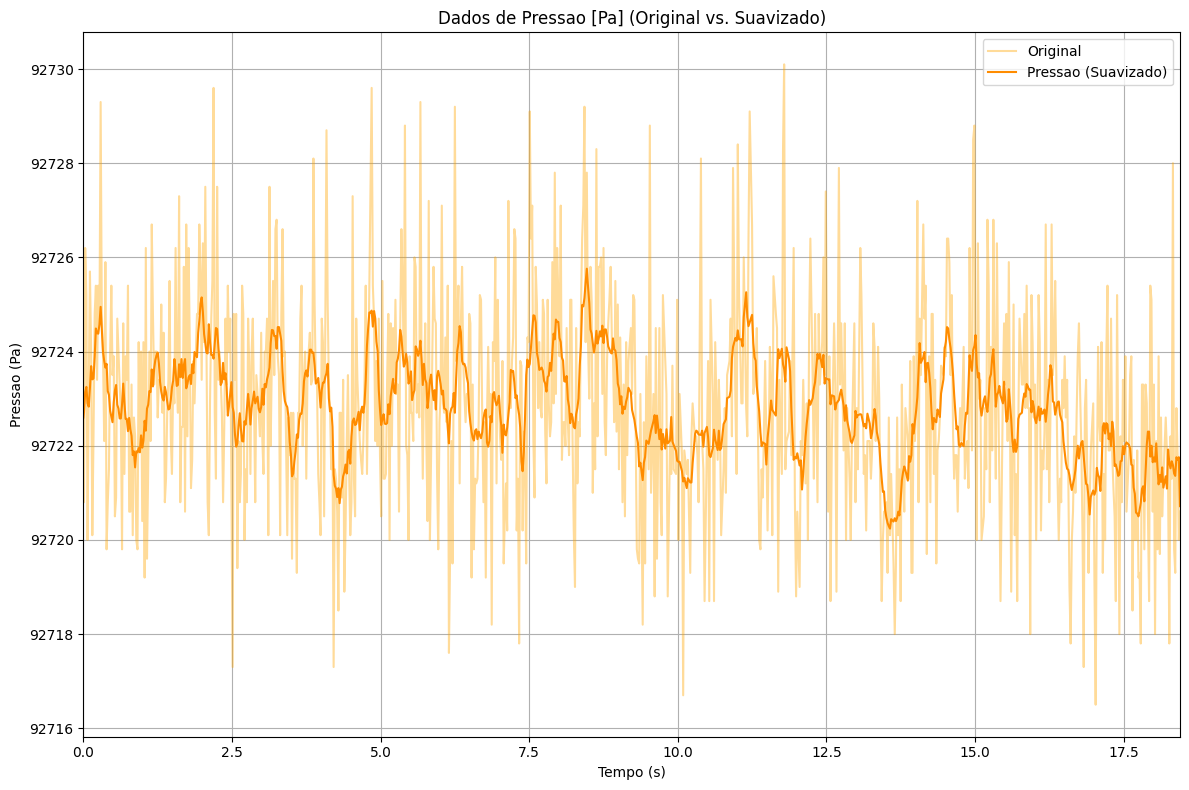

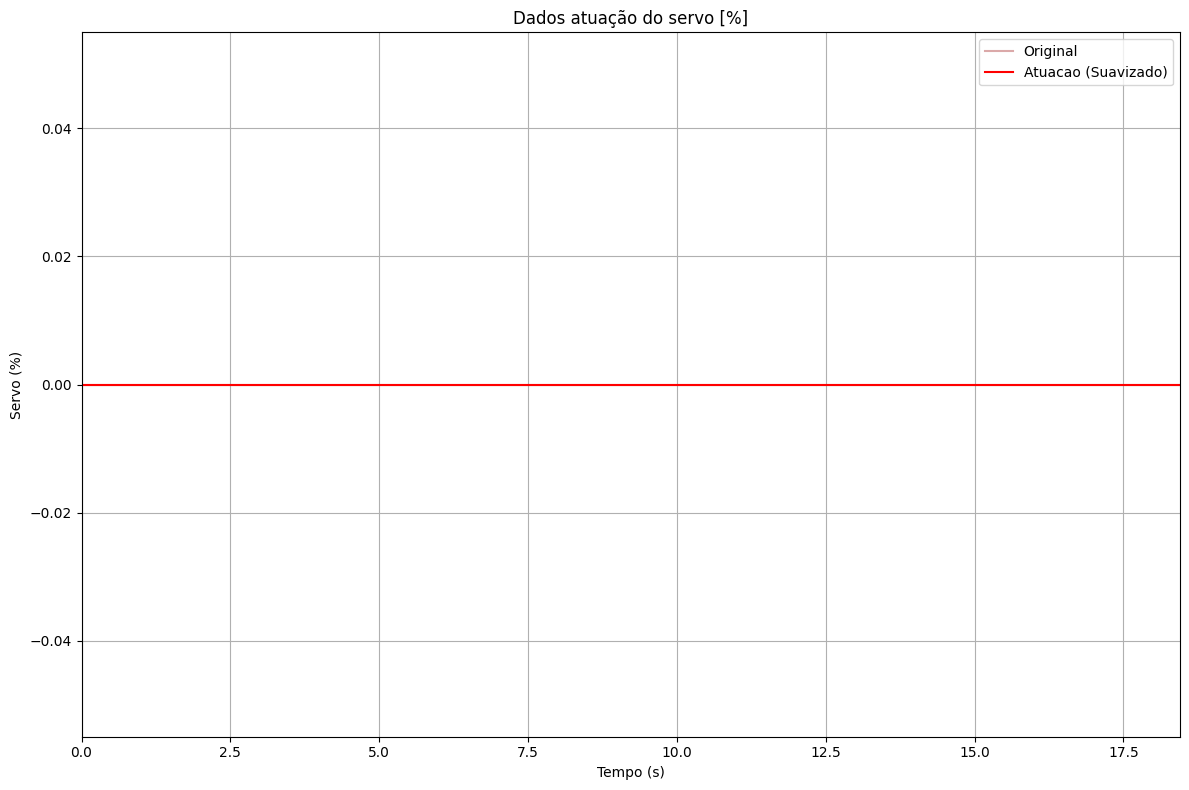

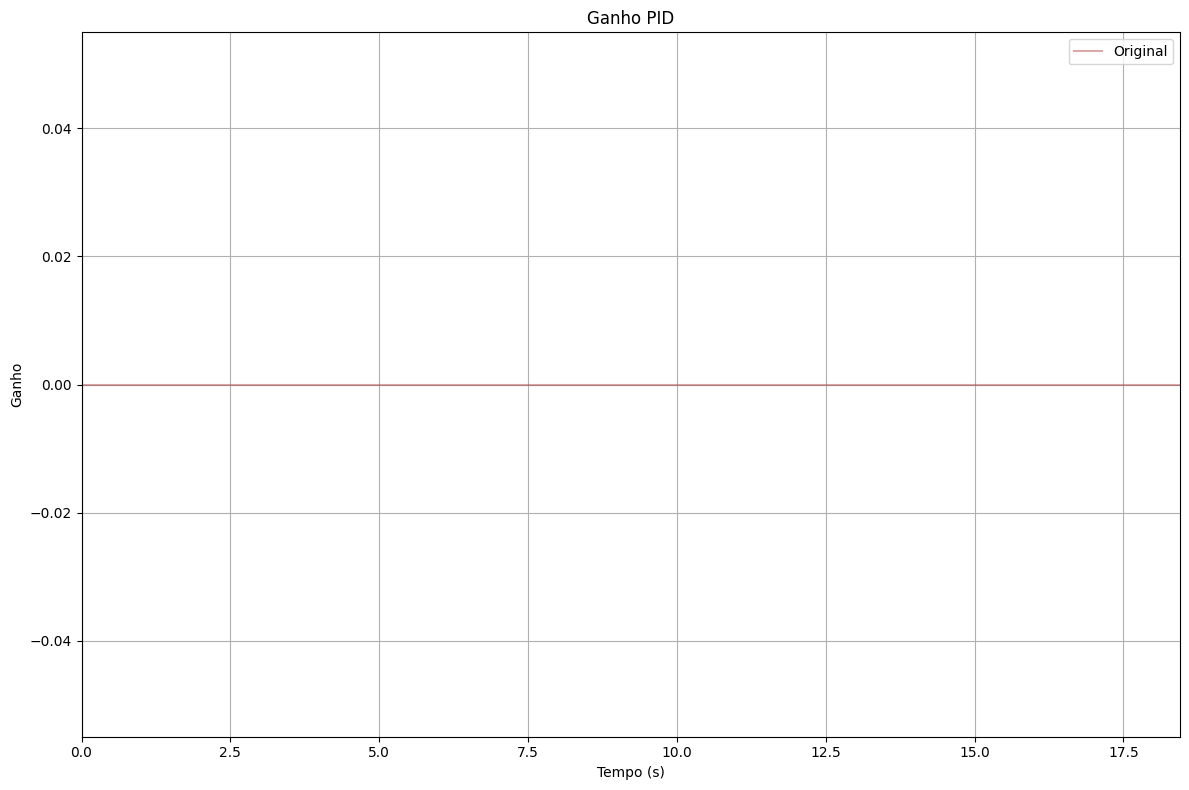

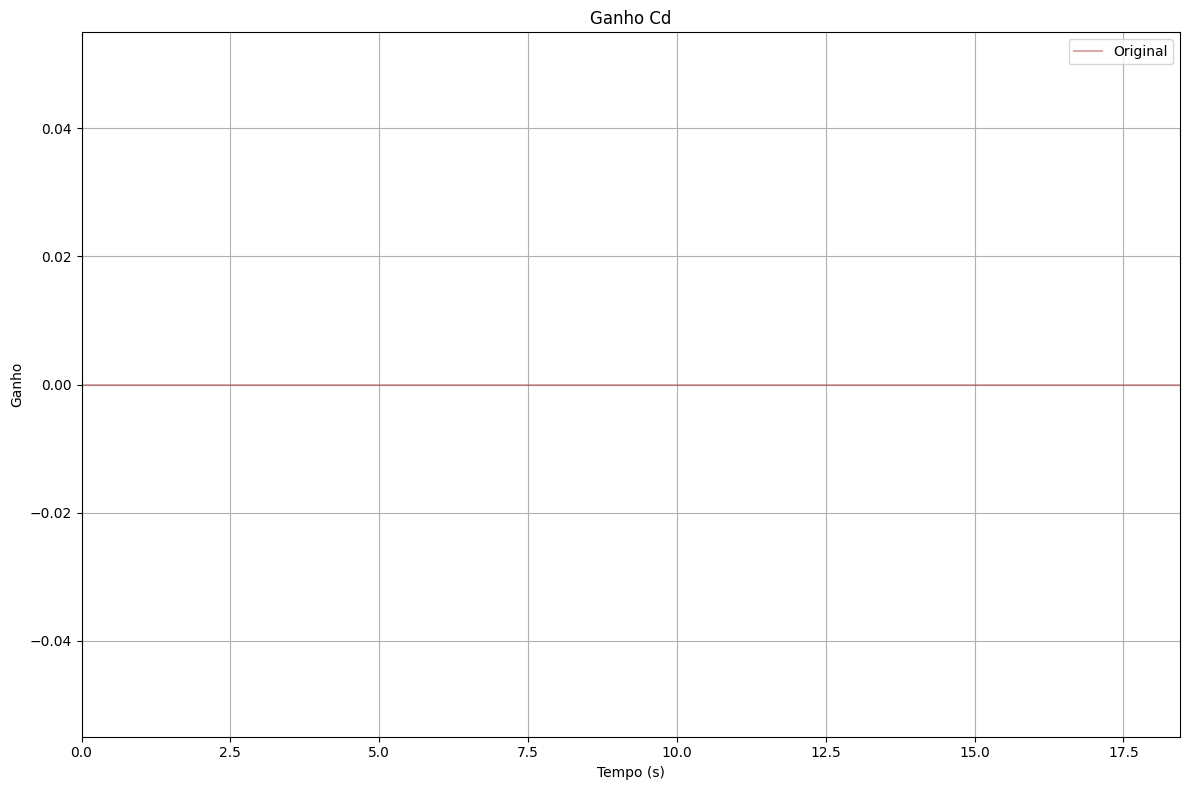

In [3]:
# Tenta carregar o arquivo CSV
try:
    df = pd.read_csv(caminho_arquivo, names=nomes_colunas, skiprows=1)
except FileNotFoundError:
    print(f"ERRO: Arquivo '{caminho_arquivo}' nao encontrado.")
    exit()
except Exception as e:
    print(f"Erro ao ler o arquivo CSV: {e}")
    exit()

if df.empty:
    print(f"O arquivo CSV '{caminho_arquivo}' esta vazio.")
    exit()

# --- Pre-processamento e Cálculo da Média Móvel ---
if 'Time[ms]' in df.columns:
    df['Time[ms]'] = df['Time[ms]'] - df['Time[ms]'].iloc[0]
    df['Time[s]'] = (df['Time[ms]'] - df['Time[ms]'].iloc[0]) / 1000.0
    eixo_x = 'Time[s]'
    unidade_tempo = 's'
else:
    print("ERRO: Coluna 'Time[ms]' não encontrada.")
    exit()

def adicionar_media_movel(df_original, nome_coluna):
    if nome_coluna in df_original.columns:
        nova_coluna_suavizada = f"{nome_coluna}_smooth"
        df_original[nova_coluna_suavizada] = df_original[nome_coluna].rolling(
            window=TAMANHO_JANELA_MEDIA_MOVEL, center=True, min_periods=1).mean()

colunas_para_suavizar = nomes_colunas[1:]
for col in colunas_para_suavizar:
    adicionar_media_movel(df, col)



ESTADOS = {
    0: 'Calibration',
    1: 'Health check',
    2: 'Waiting for launch',
    3: 'Motor burn',
    4: 'Burnout',
    5: 'Airbrake deployment',
    6: 'Apogee',
    7: 'Descent',
    8: 'Landing',
    9: 'Airbrake retraction',
}

# Cores para o fundo dos gráficos (Fases)
CORES_ESTADOS = {
    0: '#f0f0f0', # Cinza
    1: '#fffde7', # Amarelo muito claro
    2: '#ffccbc', # Laranja claro 
    3: '#ffe0b2', # Laranja 
    4: "#70da73", # Verde 
    5: '#b3e5fc', # Azul claro 
    6: '#e1bee7', # Roxo 
    7: '#dcedc8', # Verde 
    8: '#e091ad', # Rosa
    9: '#cfd8dc', # Cinza azulado
}

condicao_estado_9 = (df['Estado'] == 5) & (df['Tilt[°]'] > 20)
df.loc[condicao_estado_9, 'Estado'] = 9

def adicionar_fundo_fases(ax, df, coluna_estado='Estado'):
    """Pinta o fundo do gráfico baseado nas mudanças de estado."""
    if coluna_estado not in df.columns:
        return

    # Detecta mudanças de estado
    mudancas = df[coluna_estado].ne(df[coluna_estado].shift()).cumsum()
    grupos = df.groupby(mudancas)

    legendas_adicionadas = set()

    for _, grupo in grupos:
        estado_id = grupo[coluna_estado].iloc[0]
        inicio = grupo['Time[s]'].iloc[0]
        fim = grupo['Time[s]'].iloc[-1]
        
        cor = CORES_ESTADOS.get(estado_id, 'white')
        nome_fase = ESTADOS.get(estado_id, str(estado_id))
        
        # Pinta a área
        ax.axvspan(inicio, fim, facecolor=cor, alpha=0.4, zorder=0)
        
        # Adiciona rótulo no topo (apenas se a fase durou mais que 0.5s para não poluir)
        if (fim - inicio) > 0.5:
            # Posiciona texto no topo do gráfico
            ylim = ax.get_ylim()
            y_pos = ylim[1] - (ylim[1] - ylim[0]) * 0.05 # 5% abaixo do topo
            ax.text((inicio+fim)/2, y_pos, nome_fase, 
                    ha='center', va='top', fontsize=8, color='gray', rotation=0, fontweight='bold')

def gerar_relatorio_texto(df):
    print("="*60)
    print("RELATÓRIO DE VOO")
    print("="*60)

    burnout_val = df['AltFilt[m]'][df['Estado'] == 4].min()
    
    idx_burnout = df['AltFilt[m]'][df['Estado'] == 4].idxmin()
    
    burnout_time = df.loc[idx_burnout, 'Time[s]']
    
    print(f"BURNOUT REGISTRADO: {burnout_val:.2f} m (T+ {burnout_time:.2f}s)")
    
    apogeu_val = df['AltFilt[m]'].max()
    apogeu_val_detect = df['AltFilt[m]'][df['Estado'] == 6].max()
    
    idx_max = df['AltFilt[m]'].idxmax()
    idx_max_detect = df['AltFilt[m]'][df['Estado'] == 6].idxmax()
    
    apogeu_time = df.loc[idx_max, 'Time[s]']
    apogeu_time_detect = df.loc[idx_max_detect, 'Time[s]']
    
    print(f"APOGEU REGISTRADO: {apogeu_val:.2f} m (T+ {apogeu_time:.2f}s)")
    print(f"APOGEU DETECTADO: {apogeu_val_detect:.2f} m (T+ {apogeu_time_detect:.2f}s)")
    
    # Para as outras métricas, use a mesma lógica segura:
    vel_max = df['VelFilt[m/s]'].max()
    print(f"VELOCIDADE MÁXIMA: {vel_max:.2f} m/s")
    
    # Verifica se a coluna de aceleração existe antes de tentar acessar
    if 'AccVert[m/s^2]' in df.columns:
        acc_max = df['AccVert[m/s^2]'].max()
        print(f"ACELERAÇÃO MÁXIMA: {acc_max:.2f} m/s²")

    # Airbrakes
    if 'Servo[%]' in df.columns:
        uso_airbrake = df[df['Servo[%]'] > 0]
        if not uso_airbrake.empty:
            print(f"🛑 AIRBRAKES: Atuaram por {uso_airbrake['Time[s]'].count() * 0.02:.2f} segundos")
            print(f"   Abertura Máxima: {100*uso_airbrake['Servo[%]'].max():.1f}%")
        else:
            print("🛑 AIRBRAKES: Não atuaram.")
        
    print("="*60 + "\n")

# --- Função de formatação de eixo ---
def format_y_axis(ax):
    y_formatter = ticker.ScalarFormatter(useOffset=False)
    y_formatter.set_scientific(False)
    ax.yaxis.set_major_formatter(y_formatter)

# --- Função de Conversão de Quaternion para Euler ---
def calcular_euler_angles(df_in, prefix=''):
    """Calcula Roll, Pitch, Yaw a partir das colunas de quaternion."""
    qw = df_in[f'qW{prefix}']
    qx = df_in[f'qX{prefix}']
    qy = df_in[f'qY{prefix}']
    qz = df_in[f'qZ{prefix}']

    # Roll (rotação em torno do eixo X do corpo)
    sinr_cosp = 2 * (qw * qx + qy * qz)
    cosr_cosp = 1 - 2 * (qx**2 + qy**2)
    df_in[f'Roll_deg{prefix}'] = np.arctan2(sinr_cosp, cosr_cosp) * (180.0 / np.pi)

    # Pitch (rotação em torno do eixo Y do corpo)
    sinp = 2 * (qw * qy - qz * qx)
    sinp = np.clip(sinp, -1.0, 1.0) # Clamp para evitar erros de domínio em arcsin
    df_in[f'Pitch_deg{prefix}'] = np.arcsin(sinp) * (180.0 / np.pi)

    # Yaw (rotação em torno do eixo Z do corpo)
    siny_cosp = 2 * (qw * qz + qx * qy)
    cosy_cosp = 1 - 2 * (qy**2 + qz**2)
    df_in[f'Yaw_deg{prefix}'] = np.arctan2(siny_cosp, cosy_cosp) * (180.0 / np.pi)
    
# Calcula os ângulos de Euler para os dados originais e suavizados
if all(col in df.columns for col in ['qW', 'qX', 'qY', 'qZ']):
    # Calcula a partir dos quaternions originais
    calcular_euler_angles(df) 
    # Calcula a partir dos quaternions suavizados (da média móvel)
    calcular_euler_angles(df, prefix='_smooth') 
else:
    print("Aviso: Colunas de quaternion nao encontradas. Graficos de Euler nao serao gerados.")

# gerar_relatorio_texto(df)


# --- GRUPO 1: Cinemática Principal (Subplots Separados) ---
fig1, axs1 = plt.subplots(3, 1, sharex=True, figsize=(14, 10))
fig1.suptitle('Cinemática do Voo', fontsize=16)
# Subplot da Altitude
axs1[0].plot(df['Time[s]'], df['AltFilt[m]'], label='Original', color='lightblue', alpha=0.6)
axs1[0].plot(df['Time[s]'], df['AltFilt[m]_smooth'], label=f'Suavizado (Janela={TAMANHO_JANELA_MEDIA_MOVEL})', color='dodgerblue')
axs1[0].set_ylabel('Altitude (m)')
axs1[0].grid(True)
axs1[0].legend(loc='upper left')
format_y_axis(axs1[0])


# Subplot da Velocidade
axs1[1].plot(df['Time[s]'], df['VelFilt[m/s]'], label='Original', color='lightgreen', alpha=0.6)
axs1[1].plot(df['Time[s]'], df['VelFilt[m/s]_smooth'], label='Suavizado', color='darkgreen')
axs1[1].set_ylabel('Velocidade (m/s)')
axs1[1].grid(True)
axs1[1].legend(loc='upper left')
format_y_axis(axs1[1])

# Subplot da Aceleração
axs1[2].plot(df['Time[s]'], df['AccVert[m/s^2]'], label='Original', color='lightcoral', alpha=0.6)
axs1[2].plot(df['Time[s]'], df['AccVert[m/s^2]_smooth'], label='Suavizado', color='darkred')
axs1[2].set_ylabel('Aceleracao (m/s^2)')
axs1[2].set_xlabel(f'Tempo ({unidade_tempo})')
axs1[2].grid(True)
axs1[2].legend(loc='upper left')
axs1[2].set_ylim(-50,50)
format_y_axis(axs1[2])
axs1[2].set_xlim(tempo_espera, df['Time[s]'].iloc[-1]) 

plt.tight_layout(rect=[0, 0.03, 1, 0.95])


# --- GERAÇÃO DO GRÁFICO COMBINADO ---

# Cria a figura e o primeiro eixo Y (para Altitude)
fig, ax_alt = plt.subplots(figsize=(12,8))
fig.suptitle('Altitude e Velocidade Vertical vs. Tempo', fontsize=16)
adicionar_fundo_fases(ax_alt, df, coluna_estado='Estado')

# Marca o Apogeu
idx_max = df['AltFilt[m]'].idxmax()
ax_alt.scatter(df['Time[s]'].iloc[idx_max], df['AltFilt[m]'].iloc[idx_max], color='red', s=100, zorder=5, label='Apogeu')
ax_alt.annotate(f"{df['AltFilt[m]'].max():.1f}m", 
                (df['Time[s]'].iloc[idx_max], df['AltFilt[m]'].iloc[idx_max]),
                textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

# --- Eixo Y Esquerdo (Altitude) ---
color_alt = 'dodgerblue'
ax_alt.set_xlabel(f'Tempo ({unidade_tempo})')
ax_alt.set_ylabel('Altitude (m)', color=color_alt)
# # Plotar dados originais (com transparência)
ax_alt.plot(df[eixo_x], df['AltFilt[m]'], color=color_alt, alpha=0.3, label='Altitude (Original)')
# Plotar dados suavizados (sólidos)
ax_alt.plot(df[eixo_x], df['AltFilt[m]_smooth'], color=color_alt, label=f'Altitude (Suavizada)')
ax_alt.tick_params(axis='y', labelcolor=color_alt)
format_y_axis(ax_alt)
ax_alt.grid(True, which='both', linestyle=':', linewidth=0.5)

# --- Eixo Y Direito (Velocidade) ---
ax_vel = ax_alt.twinx()  # Cria um segundo eixo Y compartilhando o eixo X
color_vel = 'green'
ax_vel.set_ylabel('Velocidade Vertical (m/s)', color=color_vel)
# # Plotar dados originais (com transparência)
ax_vel.plot(df[eixo_x], df['VelFilt[m/s]'], color=color_vel, alpha=0.3, label='Velocidade (Original)')
# Plotar dados suavizados (sólidos)
ax_vel.plot(df[eixo_x], df['VelFilt[m/s]_smooth'], color='darkgreen', label='Velocidade (Suavizada)')
ax_vel.tick_params(axis='y', labelcolor=color_vel)
format_y_axis(ax_vel)

ax_vel.axhline(0, color='gray', linestyle='--', linewidth=1)
t_burnout = df.loc[df['Estado'] == 4, 'Time[s]'].min()
ax_vel.axvline(x=t_burnout, color='green', linestyle='--', linewidth=0.5, label=f'Burnout ({t_burnout:.2f}s)')

# --- Legenda Combinada ---
# Coleta os "handles" e "labels" de cada eixo para criar uma legenda única
lines_alt, labels_alt = ax_alt.get_legend_handles_labels()
lines_vel, labels_vel = ax_vel.get_legend_handles_labels()
ax_vel.legend(lines_alt + lines_vel, labels_alt + labels_vel, loc='upper right')

# ax_alt.set_xlim(tempo_espera, df['Time[s]'].iloc[-1]) 
fig.tight_layout(rect=[0, 0, 1, 0.95])

# plt.savefig('altitude_velocidade_combinado.png', dpi=300)

plt.show() # Exibe o gráfico

# --- GRUPO 2: Dados do Acelerômetro ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,8), sharex=True)
ax1.plot(df[eixo_x], df['AccX[g]'], alpha=0.3, color='cornflowerblue')
ax1.plot(df[eixo_x], df['AccX[g]_smooth'], color='blue', label='AccX (Suavizado)')
ax2.plot(df[eixo_x], df['AccY[g]'], alpha=0.3, color='lightgreen')
ax2.plot(df[eixo_x], df['AccY[g]_smooth'], color='green', label='AccY (Suavizado)')
ax3.plot(df[eixo_x], df['AccZ[g]'], alpha=0.3, color='lightcoral')
ax3.plot(df[eixo_x], df['AccZ[g]_smooth'], color='red', label='AccZ (Suavizado)')
fig.suptitle('Dados do Acelerometro (Original vs. Suavizado)')
ax3.set_xlabel(f'Tempo ({unidade_tempo})')
ax2.set_ylabel('Aceleracao (g)')
ax1.legend()
ax1.grid(True)
ax2.legend()
ax2.grid(True)
ax3.legend()
ax3.grid(True)
plt.ylim(-5, 5)
plt.xlim(tempo_espera, df['Time[s]'].iloc[-1]) 
format_y_axis(plt.gca())
plt.tight_layout()


# --- GRUPO 3: Dados do Giroscópio ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,8), sharex=True)
ax1.plot(df[eixo_x], df['GyroX[°/s]'], alpha=0.3, color='cornflowerblue')
ax1.plot(df[eixo_x], df['GyroX[°/s]_smooth'], color='blue', label='GyroX (Suavizado)')
ax2.plot(df[eixo_x], df['GyroY[°/s]'], alpha=0.3, color='lightgreen')
ax2.plot(df[eixo_x], df['GyroY[°/s]_smooth'], color='green', label='GyroY (Suavizado)')
ax3.plot(df[eixo_x], df['GyroZ[°/s]'], alpha=0.3, color='lightcoral')
ax3.plot(df[eixo_x], df['GyroZ[°/s]_smooth'], color='red', label='GyroZ (Suavizado)')
fig.suptitle('Dados do Giroscopio (Original vs. Suavizado)')
ax3.set_xlabel(f'Tempo ({unidade_tempo})')
ax2.set_ylabel('Velocidade Angular (°/s)')
ax1.legend()
ax1.grid(True)
ax2.legend()
ax2.grid(True)
ax3.legend()
ax3.grid(True)
# plt.ylim(-0.25, 0.25)
plt.xlim(tempo_espera, df['Time[s]'].iloc[-1]) 
format_y_axis(plt.gca())
plt.tight_layout()


# --- GRUPO 4: Dados do Magnetômetro ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12,8), sharex=True)
ax1.plot(df[eixo_x], df['MagX[uT]'], alpha=0.3, color='cornflowerblue')
ax1.plot(df[eixo_x], df['MagX[uT]_smooth'], color='blue', label='MagX (Suavizado)')
ax2.plot(df[eixo_x], df['MagY[uT]'], alpha=0.3, color='lightgreen')
ax2.plot(df[eixo_x], df['MagY[uT]_smooth'], color='green', label='MagY (Suavizado)')
ax3.plot(df[eixo_x], df['MagZ[uT]'], alpha=0.3, color='lightcoral')
ax3.plot(df[eixo_x], df['MagZ[uT]_smooth'], color='red', label='MagZ (Suavizado)')
fig.suptitle('Dados do Magnetometro (Original vs. Suavizado)')
ax3.set_xlabel(f'Tempo ({unidade_tempo})')
ax2.set_ylabel('Campo Magnetico (uT)')
ax1.legend()
ax1.grid(True)
ax2.legend()
ax2.grid(True)
ax3.legend()
ax3.grid(True)
format_y_axis(plt.gca())
plt.xlim(tempo_espera, df['Time[s]'].iloc[-1]) 
plt.tight_layout()


# --- GRUPO 5: Orientação (Ângulos de Euler) ---
if all(col in df.columns for col in ['Roll_deg', 'Pitch_deg', 'Yaw_deg']):
    fig_euler, axs_euler = plt.subplots(3, 1, sharex=True, figsize=(14, 10))
    fig_euler.suptitle('Orientacao do Foguete (Angulos de Euler)', fontsize=16)

    # Subplot do Roll
    axs_euler[0].plot(df[eixo_x], df['Roll_deg'], label='Original', color='lightcoral', alpha=0.4)
    axs_euler[0].plot(df[eixo_x], df['Roll_deg_smooth'], label=f'Suavizado (Janela={TAMANHO_JANELA_MEDIA_MOVEL})', color='darkred')
    axs_euler[0].set_ylabel('Roll (°)')
    axs_euler[0].grid(True)
    axs_euler[0].legend(loc='upper left')
    format_y_axis(axs_euler[0])

    # Subplot do Pitch
    axs_euler[1].plot(df[eixo_x], df['Pitch_deg'], label='Original', color='lightgreen', alpha=0.4)
    axs_euler[1].plot(df[eixo_x], df['Pitch_deg_smooth'], label='Suavizado', color='darkgreen')
    axs_euler[1].set_ylabel('Pitch (°)')
    axs_euler[1].grid(True)
    axs_euler[1].legend(loc='upper left')
    format_y_axis(axs_euler[1])

    # Subplot do Yaw
    axs_euler[2].plot(df[eixo_x], df['Yaw_deg'], label='Original', color='lightblue', alpha=0.4)
    axs_euler[2].plot(df[eixo_x], df['Yaw_deg_smooth'], label='Suavizado', color='dodgerblue')
    axs_euler[2].set_ylabel('Yaw (°)')
    axs_euler[2].set_xlabel(f'Tempo ({unidade_tempo})')
    axs_euler[2].grid(True)
    axs_euler[2].legend(loc='upper left')
    format_y_axis(axs_euler[2])
    axs_euler[2].set_xlim(tempo_espera, df['Time[s]'].iloc[-1])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# --- GRUPO 6: Tilt, Atuação do Servo e Pressão ---
plt.figure(figsize=(12,8))
plt.plot(df[eixo_x], df['Tilt[°]'], label='Original', color='purple', alpha=0.4)
plt.plot(df[eixo_x], df['Tilt[°]_smooth'], label='Tilt (Suavizado)', color='purple')
# plt.plot(df[eixo_x], df['AccVert[m/s^2]_smooth'], label='Suavizado', color='darkred')
plt.axhline(20, color='red', linestyle=':', label='Limite Segurança (20°)')
plt.title('Dados de Tilt[°] (Original vs. Suavizado)')
plt.xlabel(f'Tempo ({unidade_tempo})')
plt.ylabel('Tilt (°)')
plt.legend()
plt.grid(True)
format_y_axis(plt.gca())
plt.xlim(tempo_espera, df['Time[s]'].iloc[-1]) 
plt.tight_layout()

plt.figure(figsize=(12,8))
plt.plot(df[eixo_x], df['PressBMP[Pa]'], label='Original', color='orange', alpha=0.4)
plt.plot(df[eixo_x], df['PressBMP[Pa]_smooth'], label='Pressao (Suavizado)', color='darkorange')
plt.title('Dados de Pressao [Pa] (Original vs. Suavizado)')
plt.xlabel(f'Tempo ({unidade_tempo})')
plt.ylabel('Pressao (Pa)')
plt.legend()
plt.grid(True)
format_y_axis(plt.gca())
plt.xlim(tempo_espera, df['Time[s]'].iloc[-1]) 
plt.tight_layout()


plt.figure(figsize=(12,8))
plt.plot(df[eixo_x], df['Servo[%]'], label='Original', color='brown', alpha=0.4)
plt.plot(df[eixo_x], df['Servo[%]_smooth'], label='Atuacao (Suavizado)', color='red')
plt.title('Dados atuação do servo [%]')
plt.xlabel(f'Tempo ({unidade_tempo})')
plt.ylabel('Servo (%)')
plt.legend()
plt.grid(True)
format_y_axis(plt.gca())
plt.xlim(tempo_espera, df['Time[s]'].iloc[-1]) 
plt.tight_layout()

plt.figure(figsize=(12,8))
plt.plot(df[eixo_x], df['Gain1_smooth'], label='Original', color='brown', alpha=0.4)
plt.title('Ganho PID')
plt.xlabel(f'Tempo ({unidade_tempo})')
plt.ylabel('Ganho')
plt.legend()
plt.grid(True)
format_y_axis(plt.gca())
plt.xlim(tempo_espera, df['Time[s]'].iloc[-1]) 
plt.tight_layout()

plt.figure(figsize=(12,8))
plt.plot(df[eixo_x], df['Gain2'], label='Original', color='brown', alpha=0.4)
plt.title('Ganho Cd')
plt.xlabel(f'Tempo ({unidade_tempo})')
plt.ylabel('Ganho')
plt.legend()
plt.grid(True)
plt.xlim(tempo_espera, df['Time[s]'].iloc[-1]) 
format_y_axis(plt.gca())
plt.tight_layout()


# Exibir todos os gráficos gerados
plt.show()

In [4]:
df

,Time[ms],AccX[g],AccY[g],AccZ[g],GyroX[°/s],GyroY[°/s],GyroZ[°/s],MagX[uT],MagY[uT],MagZ[uT],...,Servo[%]_smooth,Gain1_smooth,Gain2_smooth,Estado_smooth,Roll_deg,Pitch_deg,Yaw_deg,Roll_deg_smooth,Pitch_deg_smooth,Yaw_deg_smooth
0,0,0.028,0.020,0.988,0.000,-0.183,0.000,0.00,0.000,0.000,...,0.0,0.0,0.0,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,10,0.026,0.022,0.990,0.000,-0.244,0.000,0.00,0.000,0.000,...,0.0,0.0,0.0,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,30,0.028,0.022,0.992,-0.061,-0.305,-0.061,0.00,0.000,0.000,...,0.0,0.0,0.0,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,50,0.027,0.021,0.984,-0.122,-0.183,0.061,0.00,0.000,0.000,...,0.0,0.0,0.0,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,70,0.027,0.022,0.990,-0.061,-0.122,0.061,0.00,0.000,0.000,...,0.0,0.0,0.0,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,18370,0.027,0.022,0.987,-0.122,-0.183,-0.122,3.31,-8.765,-59.994,...,0.0,0.0,0.0,2.0,0.169700,-2.539065,124.531349,0.184920,-2.510393,124.394921
863,18390,0.027,0.023,0.988,-0.061,-0.244,-0.061,3.31,-8.765,-59.994,...,0.0,0.0,0.0,2.0,0.163675,-2.539458,124.803152,0.173887,-2.519614,124.530298
864,18410,0.027,0.021,0.986,0.000,-0.122,0.061,3.31,-8.765,-59.994,...,0.0,0.0,0.0,2.0,0.147475,-2.545140,125.075786,0.163930,-2.527787,124.666328
865,18430,0.026,0.021,0.990,-0.061,-0.305,0.061,3.31,-8.765,-59.994,...,0.0,0.0,0.0,2.0,0.125984,-2.540585,125.348880,0.157010,-2.533732,124.802368


In [5]:
a = df["MagX[uT]_smooth"].mean() 
b = df["MagY[uT]_smooth"].mean() 
c = df["MagZ[uT]_smooth"].mean()
d = np.sqrt(a**2 + b**2 + c**2)
print(a, b, c, d)

2.7253437139561707 -7.187308535178778 -54.54580853517878 55.0847540712985
